<a href="https://colab.research.google.com/github/Plumz17/CVL_Assignment04/blob/main/CVL_Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fourth Computer Vision Assignment - Analysis of Object Detection Algorithm - Anders Emmanuel Tan (24/541351/PA/22964)
Description: In this Assignment I will be Implementing two several Object Tracking Methods (Template Matching and Optical Flow) in order to track a person within a video. Additionally, I will be manually implementing evaluation metrics in order to evaluate and analyze the performance of both methods.

For this assignment, i will be using an Object Tracking Benchmark (OTB) dataset from kaggle as can be seen in this link: (https://www.kaggle.com/datasets/zly1402875051/otb2015). Since the files provided in the dataset are in the form of multiple .jpg files, we will also be providing a function that converts those into video file so we can illustrate the algorithm's performance (since videos are just sequences of frames)

## 0. Setting Up
Description: For this first section, we will be preparing the frames that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by acquiring them from my mounted google drive folder (which contains a folder with all of the frames as well as a .txt file containing the information of the bounding boxes). Additionaly, we will also be importing the libaries that we will be using for this submission to import and process the frames. We will also be defining some helper functions to aid us in our implementation later (including one that'll combine every frame into a video)

### 0A. Importing the Files

In [367]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [368]:
# Import Important Libraries
import cv2 # For Reading Image
import numpy as np # For Manipulating Numeric types
import matplotlib.pyplot as plt # For Showing Image
import math # For Math
import os # For managing files

#Loading File using their Filenames
filename_video_walk    = "/content/drive/MyDrive/CVL_Files/video_walk"
filename_video_walk_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_walk.txt"
filename_video_dino    = "/content/drive/MyDrive/CVL_Files/video_dino"
filename_video_dino_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_dino.txt"
filename_video_skating    = "/content/drive/MyDrive/CVL_Files/video_skating"
filename_video_skating_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_skating.txt"
filename_video_ball    = "/content/drive/MyDrive/CVL_Files/video_ball"
filename_video_ball_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_ball.txt"
filename_video_cup    = "/content/drive/MyDrive/CVL_Files/video_cup"
filename_video_cup_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_cup.txt"
filename_video_person    = "/content/drive/MyDrive/CVL_Files/video_person"
filename_video_person_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_person.txt"
filename_video_occlusion    = "/content/drive/MyDrive/CVL_Files/video_occlusion"
filename_video_occlusion_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_occlusion.txt"

In [369]:
def load_frames_from_folder(folder_path):
  # Get all filenames and sort them
  frame_files = sorted(os.listdir(folder_path))
  frames = []
  for file in frame_files:
    file_path = os.path.join(folder_path, file)

    # Read image
    img = cv2.imread(file_path)

    # Convert to grayscale for ease and append it to frames
    if img is not None:
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      frames.append(img)

  return frames

In [370]:
def load_ground_truth(gt_path, delimiter=","):
  gt = []
  with open(gt_path, 'r') as f:
    for line in f:
      # Dataset ground truth is tab seperated
      line = line.strip()
      values = [float(v) for v in line.split(delimiter) if v != '']
      # Each line is x, y, width, height
      gt.append(values[:4])
  return np.array(gt, dtype=np.float32)

frames = load_frames_from_folder(filename_video_skating)
gt_boxes  = load_ground_truth(filename_video_skating_gt, ",")

### 0B. Defining Helper Functions

In [371]:
def show(img): # Helper function to show frame
  if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(img, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")
  plt.show()

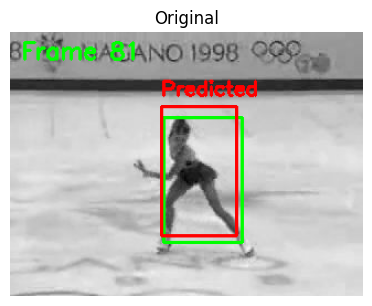

In [372]:
def draw_ground_truth(frames, gt_boxes, frame_idx):
  frame = frames[frame_idx]
  # Change frame into BGR if it isn't already to draw colored box
  if len(frame.shape) == 2:
    annotated_frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
  else:
    annotated_frame = frame.copy()
  # Unpack the the gt_box
  x, y, w, h = [int(v) for v in gt_boxes[frame_idx]]

  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
  cv2.putText(annotated_frame, f"Frame {frame_idx+1}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
  return annotated_frame

# Pass the frames and gt_boxes and the index of that specific frame
annotated_frame = draw_ground_truth(frames, gt_boxes, 0)

def draw_pred_box(frames, gt_boxes, pred_box, frame_idx):
  # Show GT box too
  annotated_frame = draw_ground_truth(frames, gt_boxes, frame_idx)
  # Unpack predicted box
  x, y, w, h = [int(v) for v in pred_box]

  # Draw predicted box in red
  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
  cv2.putText(annotated_frame, "Predicted", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

  return annotated_frame

predicted_frame = draw_pred_box(frames, gt_boxes, gt_boxes[83], frame_idx=80)

show(predicted_frame)

In [373]:
#Helper Function to play the frames as a video
def save_frames_as_video(frames, filename, output_path="/content", fps=30, with_gt = False):
  h, w = frames[0].shape[:2]
  # Define video writer
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  full_path = f"{output_path}/{filename}.mp4"
  out = cv2.VideoWriter(full_path, fourcc, fps, (w, h), isColor=True)
  for i, frame in enumerate(frames):
    if with_gt:
      # Use the thre previous function
      out_frame = draw_ground_truth(frames, gt_boxes, i)
    else:
      out_frame = frame
    out.write(out_frame)
  out.release()

save_frames_as_video(frames, "output_gt", with_gt=True)

## 1. Template Matching
Description: For my implementation of Template Matching i will be using SSD (Sum of Squared Differences) as the similarity metric to calculate the similiar (or in this case, how different) the template image from the "patch" that the algorithm is checking. Moreover, instead of running the template matching algorithm every frame, we will be keeping track of the previous frames' predicted bounding box position and then comparing the previous bounding box with several candidate boxes within that search radius (this is done because pak wahyono uses template matching as a tracking algorithm not a detection algorithm in class). On top of that, we will also be calculating the IoU for every frame to measure the performance of our algorithm compared to the ground truth provided in the dataset. Finally, we will be calculating the average IoU, the true positive rate, as well as plotting the IoU over time, so we can know precisely when the algorithm fails or suceeds.

### 1A. Template Matching Implementation

In [374]:
#Helper Function to Extract a template from a given bounding box (first bounding box)
def extract_template(frame, bbox):
  x, y, w, h = [int(v) for v in bbox]
  return frame[y:y+h, x:x+w].copy()

In [375]:
#Function to calculate sum of squared differences
def compute_ssd(template, patch):
    return np.sum((patch.astype(np.float32) - template.astype(np.float32)) ** 2)

In [376]:
#Function to generate candidates from current bounding box
def generate_candidates(frame, current_box, search_radius, step):
  candidate_x, candidate_y, candidate_w, candidate_h = [int(v) for v in current_box]
  candidates = []
  frame_h, frame_w = frame.shape[:2]
  for dy in range(-search_radius, search_radius + 1, step):
    for dx in range(-search_radius, search_radius + 1, step):
      # Shift the current box by (dx, dy)
      new_x = candidate_x + dx
      new_y = candidate_y + dy
      if new_x < 0 or new_y < 0:
        continue
      if new_x + candidate_w > frame_w or new_y + candidate_h > frame_h:
        continue
      candidates.append((new_x, new_y, candidate_w, candidate_h))
  return candidates

In [377]:
#Function to find the box with the lowest sum of squared differences (SSD)
def find_best_match(frame, template, candidates):
  best_score = float('inf')
  best_box = None
  for (candidate_x, candidate_y, candidate_w, candidate_h) in candidates:
    patch = frame[candidate_y:candidate_y+candidate_h, candidate_x:candidate_x+candidate_w]
    score = compute_ssd(template, patch)
    if score < best_score:
      best_score = score
      best_box = (candidate_x, candidate_y, candidate_w, candidate_h)
  return best_box

In [378]:
def template_matching(frames, initial_box, search_radius=20, step=1):
  #Define template and first box as the first ground truth's bounding box
  template = extract_template(frames[0], initial_box)
  pred_boxes = [initial_box]
  current_box = initial_box
  #Find box with highest SSD with the template
  for frame in frames[1:]:
    candidates = generate_candidates(frame, current_box, search_radius, step)
    best_box = find_best_match(frame, template, candidates)
    pred_boxes.append(best_box)
    current_box = best_box
  return pred_boxes

In [379]:
initial_box = gt_boxes[0]  # Use ground truth box from frame 0
pred_boxes = template_matching(frames, initial_box, search_radius=20, step=1)

In [380]:
#Annotate frames with predictions
annotated_frames = []
for i, frame in enumerate(frames):
  annonated_frame = draw_pred_box(frames, gt_boxes, pred_boxes[i], i)
  annotated_frames.append(annonated_frame)

# Export as Video
save_frames_as_video(annotated_frames, "output_tm")

### 1B. Template Matching Evaluation

In [381]:
def compute_iou(boxa, boxb):
  xa, ya, wa, ha = boxa
  xb, yb, wb, hb = boxb
  xai = max(xa, xb)
  xbi = min(xa+wa, xb+wb)
  yai = max(ya, yb)
  ybi = min(ya+ha, yb+hb)
  inter = max(0, xbi - xai) * max(0, ybi - yai)
  union = wa * ha + wb * hb - inter
  if union > 0:
    return inter / union
  else:
    return 0.0

compute_iou(pred_boxes[1], gt_boxes[1])

np.float32(1.0)

In [382]:
def compute_center_error(boxa, boxb):
  xa, ya, wa, ha = boxa
  xb, yb, wb, hb = boxb
  cx_a = xa + wa / 2
  cy_a = ya + ha / 2
  cx_b = xb + wb / 2
  cy_b = yb + hb / 2
  return math.sqrt((cx_a - cx_b) ** 2 + (cy_a - cy_b) ** 2)

In [383]:
tm_ious = []
for i in range(len(pred_boxes)):
  iou = compute_iou(pred_boxes[i], gt_boxes[i])
  tm_ious.append(iou)

In [384]:
tm_center_errors = []
for i in range(len(pred_boxes)):
  err = compute_center_error(pred_boxes[i], gt_boxes[i])
  tm_center_errors.append(err)

avg_center_error = sum(tm_center_errors) / len(tm_center_errors)
print("Template Matching - Average Center Point Error (px):", avg_center_error)

Template Matching - Average Center Point Error (px): 12.58792835806212


In [385]:
avg_iou = sum(tm_ious) / len(tm_ious)
iou_tp = []
for iou in tm_ious:
  if iou >= 0.5:
    iou_tp.append(iou)
true_positive_rate = len(iou_tp) / len(tm_ious)
print("Template Matching - Average IoU:", avg_iou)
print("Template Matching - True Positive Rate (Percentage of IoU >= 0.5):", true_positive_rate)

Template Matching - Average IoU: 0.6049447
Template Matching - True Positive Rate (Percentage of IoU >= 0.5): 0.75625


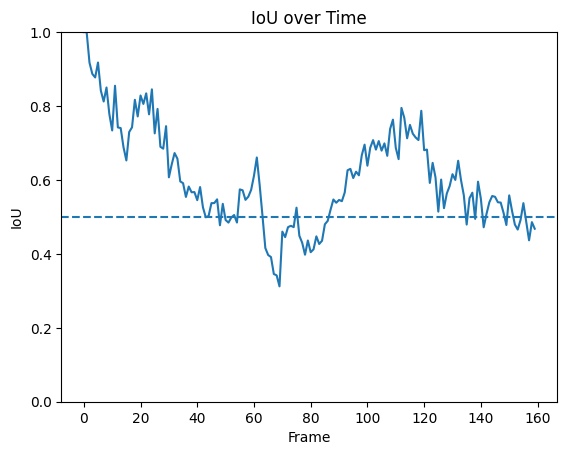

In [386]:
#Show IoU over time
plt.figure()
plt.plot(tm_ious)
plt.xlabel("Frame")
plt.ylabel("IoU")
plt.title("IoU over Time")
plt.ylim(0, 1)  # IoU is between 0 and 1
plt.axhline(y=0.5, linestyle='--')
plt.show()

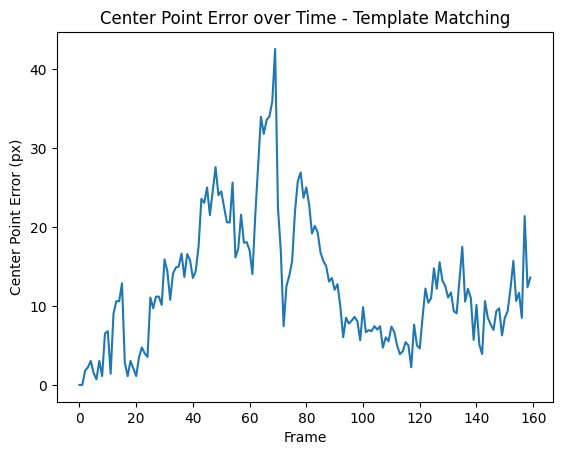

In [387]:
plt.figure()
plt.plot(tm_center_errors)
plt.xlabel("Frame")
plt.ylabel("Center Point Error (px)")
plt.title("Center Point Error over Time - Template Matching")
plt.show()

### 1C. Template Matching Analysis
Analysis: From the evaluation results, we have extracted that the Average IoU of the predicted bounding box and ground truth is ~67.8% with a true positive rate of ~84.4% (meaning that 84.4% of the predicted bounding box meet the detection threshold, in this case 50%), both of these data showcases that the template matching method resulted in a moderate performance in tracking the object (in this case a person). Additionally, if we plot the IoU over time, we can see that the algorithm starts off strong in the first ~67 frames with the IoU consistently achieving above 0.8, suggesting the model handles the first few frames quite well, but it worsens after 70th frame. This might stem from the fact that my implementation of template matching assumes the object remains at a consistent scale throughout the sequence. Since the person in the video is walking further from the camera, the person itself will appear smaller as time passes, which makes the "patch" becomes less similar with the template as time marches on. Moreover, we can also observe that the performance dropped significantly during the 80th frame, that's likely due to another problem with template matching which is object occlusion. In the video, around the 80th frame, the person is occluded by a pole, which detrimentally affects the performance of the IoU. In Future Implementations, we can solve both of these issues using image pyramids (where we compare the object with the templates of different resolutions and pick the best match) to handle scale variation, and by incorporating some sort of re-detection mechanism to recover from occlusion.

## 2. Optical Flow
Description:

### 2A. Optical Flow Implementation

In [388]:
# Compute the images' gradients
def compute_gradients(frame1, frame2):
  f1 = frame1.astype(np.float32)
  f2 = frame2.astype(np.float32)
  # Compute Intensity changes from left to right
  Ix = (np.roll(f1, -1, axis=1) - np.roll(f1, 1, axis=1) + np.roll(f2, -1, axis=1) - np.roll(f2, 1, axis=1)) / 4.0
  # Compute Intensity changes from top to bottom
  Iy = (np.roll(f1, -1, axis=0) - np.roll(f1, 1, axis=0) + np.roll(f2, -1, axis=0) - np.roll(f2, 1, axis=0)) / 4.0
  # Compute Intensity changes over time
  It = f2 - f1
  return Ix, Iy, It

In [389]:
# Apply Lucas Kanade on a single point
def lucas_kanade_point(Ix, Iy, It, px, py, win=7):
  h, w = Ix.shape
  half = win
  # Clamp to image boundaries
  y0, y1 = max(0, py - half), min(h, py + half + 1)
  x0, x1 = max(0, px - half), min(w, px + half + 1)

  # Flatten the patch into 1D arrays
  ix = Ix[y0:y1, x0:x1].flatten()
  iy = Iy[y0:y1, x0:x1].flatten()
  it = It[y0:y1, x0:x1].flatten()

  # Compute components of A^T A and A^T b for least squares
  Sxx = np.sum(ix * ix)
  Syy = np.sum(iy * iy)
  Sxy = np.sum(ix * iy)
  Sxt = np.sum(ix * it)
  Syt = np.sum(iy * it)

  AtA = np.array([[Sxx, Sxy],
                [Sxy, Syy]])
  Atb = np.array([-Sxt, -Syt])

  # If det ≈ 0, the patch has no texture to track
  if abs(np.linalg.det(AtA)) < 1e-3:
    return 0.0, 0.0

  # Solve for t = (u, v) = AtA * Atb
  u, v = np.linalg.solve(AtA, Atb)
  return u, v

In [390]:
def optical_flow_tracking(frames, initial_box, win=7, grid_step=5):
  box_x, box_y, box_w, box_h = [int(v) for v in initial_box]
  predicted_boxes = [(box_x, box_y, box_w, box_h)]  # Frame 0: use GT as starting position

  for i in range(1, len(frames)):
    previous_frame = frames[i - 1]
    current_frame  = frames[i]
    # Compute spatial (Ix, Iy) and temporal (It) gradients across the whole frame
    Ix, Iy, It = compute_gradients(previous_frame, current_frame)
    # Build a grid of evenly-spaced points inside the current bounding box
    point_xs = range(box_x + grid_step, box_x + box_w - grid_step, grid_step)
    point_ys = range(box_y + grid_step, box_y + box_h - grid_step, grid_step)
    # Estimate the flow vector (u, v) at each grid point using Lucas-Kanade
    flow_vectors = []
    for point_y in point_ys:
      for point_x in point_xs:
        u, v = lucas_kanade_point(Ix, Iy, It, point_x, point_y, win=win)
        flow_vectors.append((u, v))
    # Take the median across all points to get one reliable (u, v) for the whole box
    if len(flow_vectors) > 0:
      flows = np.array(flow_vectors)
      shift_x = np.median(flows[:, 0])
      shift_y = np.median(flows[:, 1])
    else:
      shift_x, shift_y = 0.0, 0.0
    # Shift the box by the median flow
    box_x = int(round(box_x + shift_x))
    box_y = int(round(box_y + shift_y))
    # Clamp the box so it doesn't go outside the frame boundaries
    frame_h, frame_w = current_frame.shape[:2]
    box_x = max(0, min(box_x, frame_w - box_w))
    box_y = max(0, min(box_y, frame_h - box_h))
    predicted_boxes.append((box_x, box_y, box_w, box_h))
  return predicted_boxes

In [391]:
initial_box = gt_boxes[0]
of_pred_boxes  = optical_flow_tracking(frames, initial_box)

In [392]:
# Annotate and save as video
of_annotated_frames = []
for i, frame in enumerate(frames):
  annotated = draw_pred_box(frames, gt_boxes, of_pred_boxes[i], i)
  of_annotated_frames.append(annotated)

save_frames_as_video(of_annotated_frames, "output_of")

### 2B. Optical Flow Evaluation

In [393]:
of_ious = []
for i in range(len(of_pred_boxes)):
  iou = compute_iou(of_pred_boxes[i], gt_boxes[i])
  of_ious.append(iou)

In [394]:
of_avg_iou = sum(of_ious) / len(of_ious)
of_tp = [iou for iou in of_ious if iou >= 0.5]
of_true_positive_rate = len(of_tp) / len(of_ious)

print("Optical Flow - Average IoU:", of_avg_iou)
print("Optical Flow - True Positive Rate (IoU >= 0.5):", of_true_positive_rate)

Optical Flow - Average IoU: 0.61949563
Optical Flow - True Positive Rate (IoU >= 0.5): 0.81875


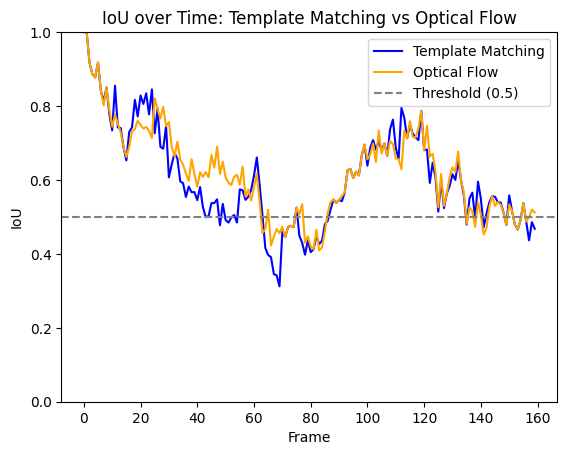

In [395]:
# Compare both methods side by side
plt.figure()
plt.plot(tm_ious, label="Template Matching", color="blue")
plt.plot(of_ious, label="Optical Flow", color="orange")
plt.xlabel("Frame")
plt.ylabel("IoU")
plt.title("IoU over Time: Template Matching vs Optical Flow")
plt.ylim(0, 1)
plt.axhline(y=0.5, linestyle='--', color='gray', label='Threshold (0.5)')
plt.legend()
plt.show()

In [396]:
of_center_errors = []
for i in range(len(of_pred_boxes)):
  err = compute_center_error(of_pred_boxes[i], gt_boxes[i])
  of_center_errors.append(err)

of_avg_center_error = sum(of_center_errors) / len(of_center_errors)
print("Optical Flow - Average Center Point Error (px):", of_avg_center_error)

Optical Flow - Average Center Point Error (px): 9.492035363702493


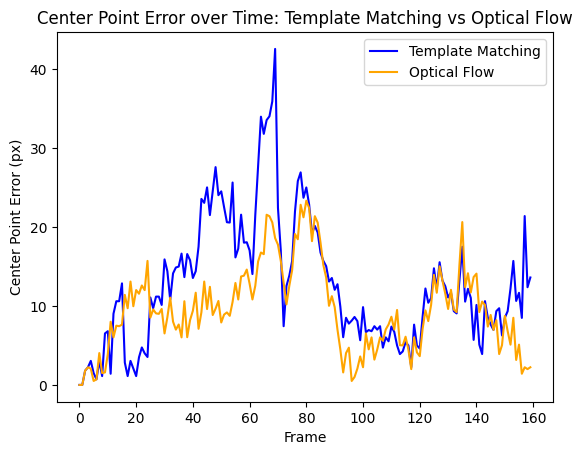

In [397]:
plt.figure()
plt.plot(tm_center_errors, label="Template Matching", color="blue")
plt.plot(of_center_errors, label="Optical Flow", color="orange")
plt.xlabel("Frame")
plt.ylabel("Center Point Error (px)")
plt.title("Center Point Error over Time: Template Matching vs Optical Flow")
plt.legend()
plt.show()

### 2C. Optical Flow Analysis
Analysis: